# Earth's radiation budget

## Introduction

The "General Circulation of the Atmosphere" is the science of understanding the mean flow on scales from synoptic to global
- What does it do?
- What does it look like?
- How do all the pieces fit together?

The circulation is fundamentally driven by two factors:
- Differential heating via radiation
- Rotation

In these notes we will begin exploring the first of those two factors: radiation and the energy budget of the Earth.

## Earth's Radiation Budget

:::{figure} ../images/stephens2012.png
:alt: Earth's Energy Balance
:width: 800px

The global annual mean energy budget of Earth for the approximate period 2000–2010. All fluxes are in W m$^{–2}$. Solar fluxes are in yellow and infrared fluxes in pink. The four flux quantities in purple-shaded boxes represent the principal components of the atmospheric energy balance. Source: {cite:t}`Stephens:2012a`
:::

## Incoming solar radiation

Computing the incident sunlight hitting the Earth is a geometrical problem with a known solution so long as we know the details of the Earth's orbit. For details, see [this lecture in Brian Rose's *The Climate Laboratory*](https://brian-rose.github.io/ClimateLaboratoryBook/courseware/insolation)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
fsize = (10,6)  # A default figure size

In [3]:
import climlab

lat = np.linspace( -90., 90., 500)
days = np.arange(0., 1., 0.001) * climlab.utils.constants.days_per_year

Q = climlab.solar.insolation.daily_insolation( lat, days )

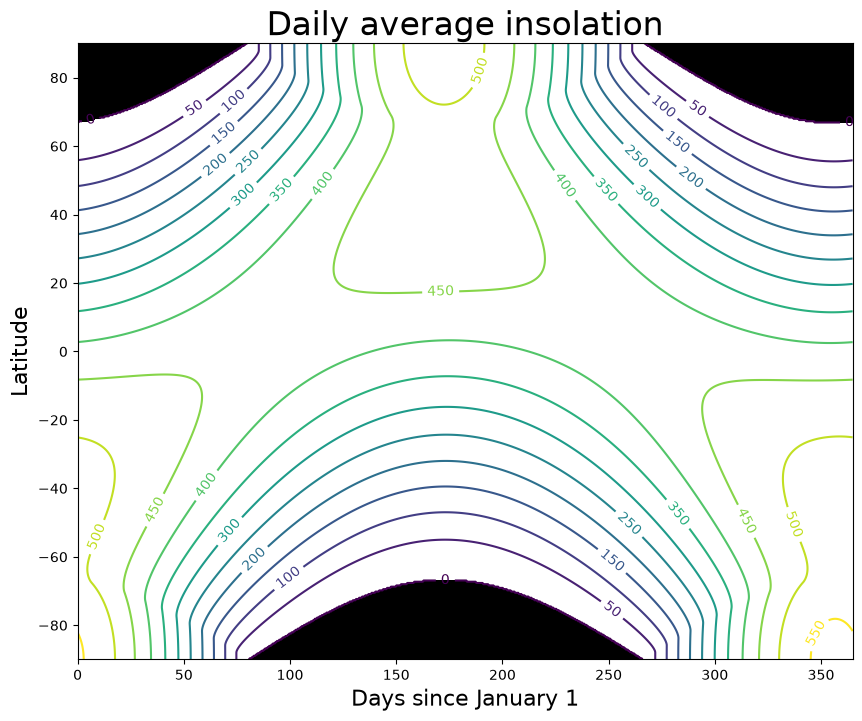

In [4]:
fig, ax = plt.subplots(figsize=(10,8))
CS = ax.contour( days, lat, Q , levels = np.arange(0., 600., 50.) )
ax.clabel(CS, CS.levels, inline=True, fmt='%1.0f', fontsize=10)
ax.set_xlabel('Days since January 1', fontsize=16 )
ax.set_ylabel('Latitude', fontsize=16 )
ax.set_title('Daily average insolation', fontsize=24 )
ax.contourf ( days, lat, Q, levels=[-1000., 0.], colors='k' );

## CERES EBAF data

The [CERES-EBAF](https://ceres.larc.nasa.gov) product is described by {cite:t}`Kato:2018a`.

In [5]:
# path_to_roselab = '/nfs/roselab_rit' # from DAES servers
path_to_roselab = '/Volumes/roselab_rit' # mounted on my laptop
ceres_URL = path_to_roselab + '/data/CERES_EBAF/CERES_EBAF_Ed4.1_200003-202202.nc'

ceres = xr.open_dataset(ceres_URL)
ceres

<xarray.Dataset> Size: 3GB
Dimensions:                      (time: 264, lat: 180, lon: 360)
Coordinates:
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 202...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
Data variables: (12/41)
    toa_sw_all_mon               (time, lat, lon) float32 68MB ...
    toa_lw_all_mon               (time, lat, lon) float32 68MB ...
    toa_net_all_mon              (time, lat, lon) float32 68MB ...
    toa_sw_clr_c_mon             (time, lat, lon) float32 68MB ...
    toa_lw_clr_c_mon             (time, lat, lon) float32 68MB ...
    toa_net_clr_c_mon            (time, lat, lon) float32 68MB ...
    ...                           ...
    sfc_net_tot_all_mon          (time, lat, lon) float32 68MB ...
    sfc_net_tot_clr_c_mon        (time, lat, lon) float32 68MB ...
    sfc_net_tot_clr_t_mon        (time, lat, lon) float32 68MB ...
    sfc_cre_net_sw_mon           (time, lat, lon) float32 68MB ...
    sfc_cre_net_lw_mon           (time, lat, lon) float32 68MB ...
    sfc_cre_net_tot_mon          (time, lat, lon) float32 68MB ...
Attributes:
    title:        CERES EBAF TOA and Surface Fluxes. Monthly Averages and 07/...
    institution:  NASA Langley Research Center
    Conventions:  CF-1.4
    comment:      Climatology from 07/2005 to 06/2015
    version:      Edition 4.1; Release Date June 8, 2021
    DOI:          10.5067/TERRA-AQUA/CERES/EBAF_L3B004.1

### Computing monthly climatologies of CERES data

We can use Xarray's `groupby` method to easily applying averaging operators over each calendar month.

In [6]:
solar_clim = ceres.solar_mon.mean(dim='lon').groupby("time.month").mean()
solar_clim

<xarray.DataArray 'solar_mon' (month: 12, lat: 180)> Size: 9kB
array([[495.6182  , 495.4778  , 495.17365 , ...,   0.      ,   0.      ,
          0.      ],
       [305.63635 , 305.54062 , 305.34952 , ...,   0.      ,   0.      ,
          0.      ],
       [ 58.755447,  59.712624,  61.63352 , ...,  22.853022,  20.908606,
         19.937273],
       ...,
       [212.32726 , 212.25655 , 212.129   , ...,   0.      ,   0.      ,
          0.      ],
       [440.87726 , 440.72968 , 440.47214 , ...,   0.      ,   0.      ,
          0.      ],
       [549.2     , 549.04376 , 548.70966 , ...,   0.      ,   0.      ,
          0.      ]], shape=(12, 180), dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Attributes:
    long_name:      Incoming Solar Flux, Monthly Means
    standard_name:  Incoming Solar Flux
    CF_name:        toa_incoming_shortwave_flux
    comment:        none
    units:          W m-2
    valid_min:            0.00000
    valid_max:            800.000

### The monthly mean insolation as represented in CERES data

In [7]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

<a list of 32 text.Text objects>

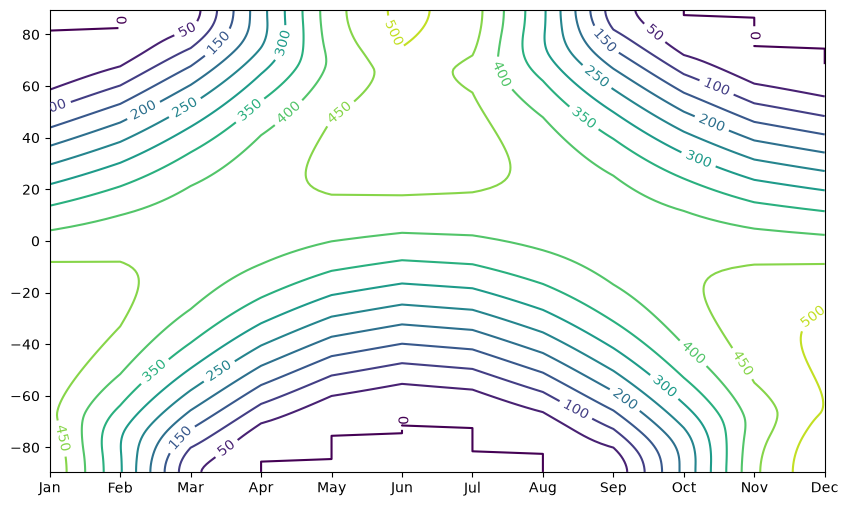

In [8]:
fig, ax = plt.subplots(figsize=fsize)
levels = np.arange(0., 600., 50.)
CS = ax.contour(months, ceres.lat, solar_clim.transpose(), levels=levels)
ax.clabel(CS, CS.levels, inline=True, fontsize=10)

In [9]:
def annual_line_plot(da, title=''):
    '''A little helper function to make some nice line plots of annual means compared to January and July'''
    fig = plt.figure(figsize=fsize)
    da.mean(dim='month').plot(label='Annual', linewidth=3)
    for month_index in [0,6]:
        da.isel(month=month_index).plot(label=months[month_index])
    plt.legend()
    plt.xlim([-90,90])
    plt.grid()
    plt.title(title, fontsize=18);

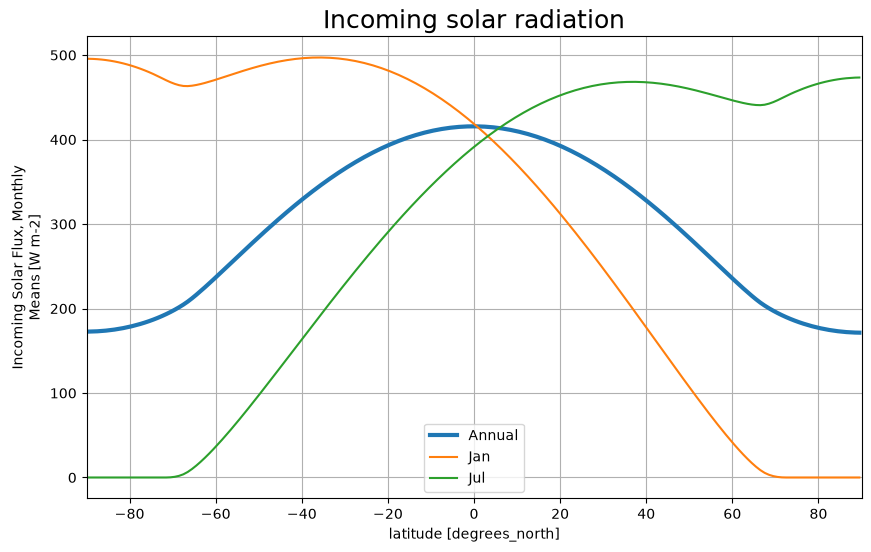

In [10]:
annual_line_plot(solar_clim, title='Incoming solar radiation')

### Albedo

The ratio of outgoing to incoming SW radiation:

$$ \alpha = \frac{F_{SW}^{\uparrow}}{F_{SW}^{\downarrow}} $$

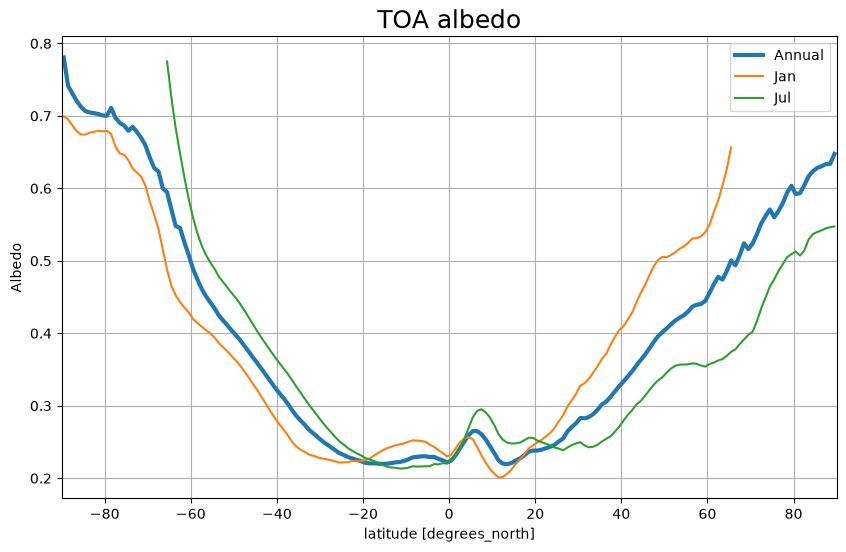

In [11]:
# masking out points where the insolation is near zero
ztoa_sw_all_clim = ceres.toa_sw_all_mon.mean(dim='lon').groupby("time.month").mean()

albedo = ztoa_sw_all_clim / solar_clim.where(solar_clim > 10.)  

annual_line_plot(albedo, title='TOA albedo')
plt.ylabel('Albedo');

### Absorbed shortwave radiation

The residual between what comes in and what goes out:

$$\text{ASR} = F_{SW}^{\downarrow} - F_{SW}^{\uparrow} = F_{SW}^{\downarrow} (1-\alpha)$$

Text(0, 0.5, 'flux (W m$^{-2}$)')

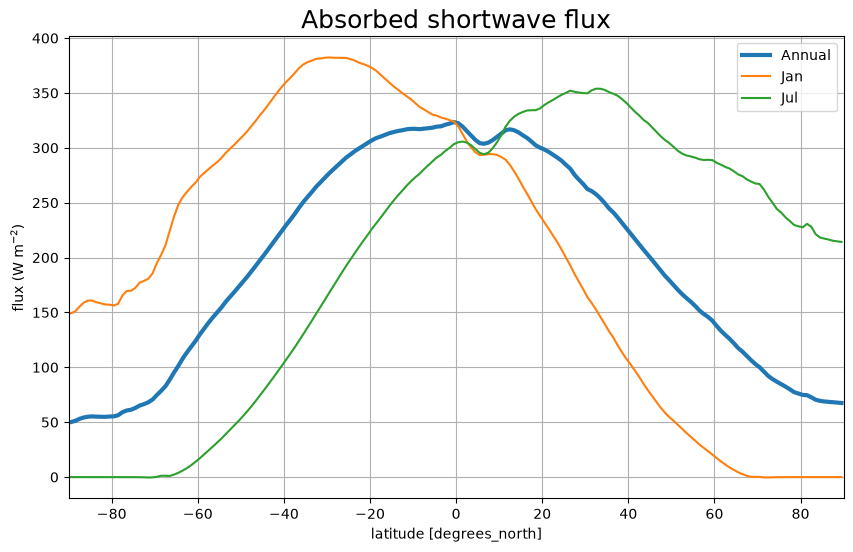

In [12]:
absorbedSW = solar_clim - ztoa_sw_all_clim

annual_line_plot(absorbedSW, title='Absorbed shortwave flux')
plt.ylabel('flux (W m$^{-2}$)')

### Outgoing longwave radiation

$$ \text{OLR} = F_{LW}^{\uparrow} $$

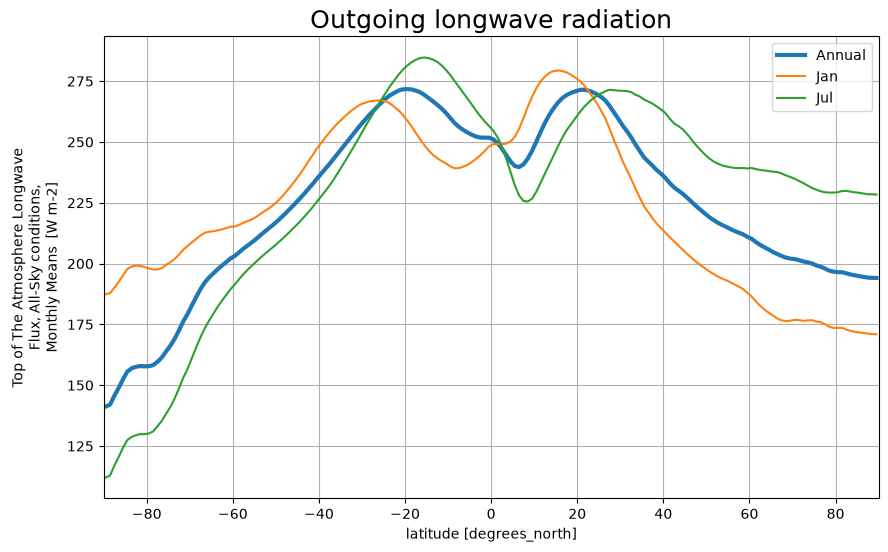

In [13]:
ztoa_lw_all_clim = ceres.toa_lw_all_mon.mean(dim='lon').groupby("time.month").mean()

annual_line_plot(ztoa_lw_all_clim, title='Outgoing longwave radiation')

### Net radiation at TOA

The net radiation is the difference between Absorbed Solar Radiation (ASR) and the Outgoing Longwave Radiation (OLR):

$$ F_{net}^{\downarrow} = \text{ASR} - \text{OLR} = F_{SW}^{\downarrow} (1-\alpha) - F_{LW}^{\uparrow} $$

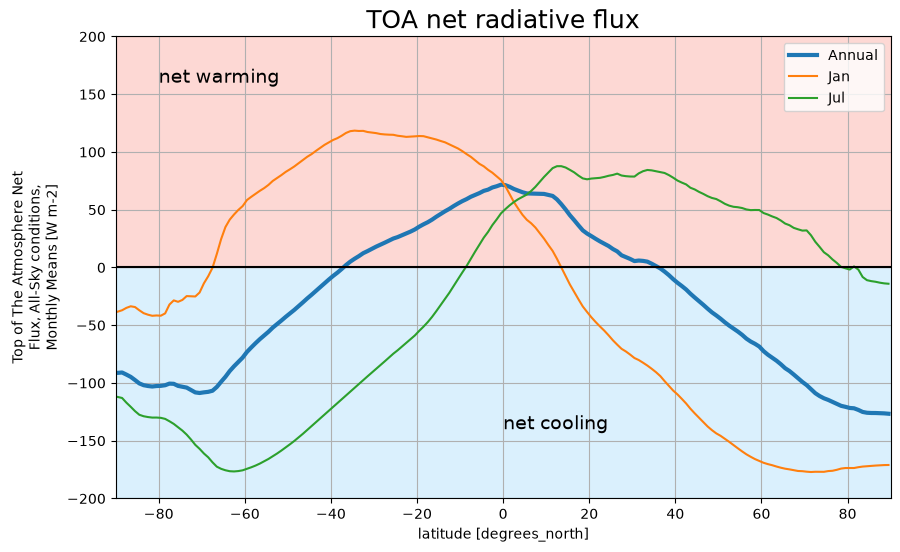

In [14]:
ztoa_net_all_clim = ceres.toa_net_all_mon.mean(dim="lon").groupby("time.month").mean()

annual_line_plot(ztoa_net_all_clim, title='TOA net radiative flux')
ylim = [-200, 200]
plt.plot([-90,90], [0,0], color='black')
plt.fill_between([-90,90], [ylim[0], ylim[0]], alpha=0.3, color='lightskyblue')
plt.text(-80, 160, 'net warming', fontsize=14)
plt.fill_between([-90,90], [ylim[1], ylim[1]], alpha=0.3, color='salmon')
plt.text(0, -140, 'net cooling', fontsize=14)
plt.ylim(ylim);

## Hemispheric energy balance

:::{figure} https://ars.els-cdn.com/content/image/1-s2.0-S0169809515002070-gr3.jpg
:alt: Earth's Hemispheric Energy Balance
:width: 800px

The annual-hemispheric mean energy balance of Earth. Unless specified otherwise, all TOA and surface numbers are in W m$^{−2}$. Fluxes of sunlight entering and leaving the TOA and surface are in yellow and infrared fluxes are red. No hemispheric surface turbulent fluxes are given. Source: {cite:t}`Stephens:2015a`
:::

### Energy storage by latitude and season

#### A published version

:::{figure} https://ars.els-cdn.com/content/image/1-s2.0-S0169809515002070-gr7.jpg
:alt: Heat storage of the Earth–atmosphere system
:width: 800px

Heat storage of the Earth–atmosphere system according to a 14 year average of CERES TOA net flux (in W m$^{−2}$) as a function of latitude and season. Source: {cite:t}`Stephens:2015a`
:::

#### And our own version based on the full CERES-EBAF dataset

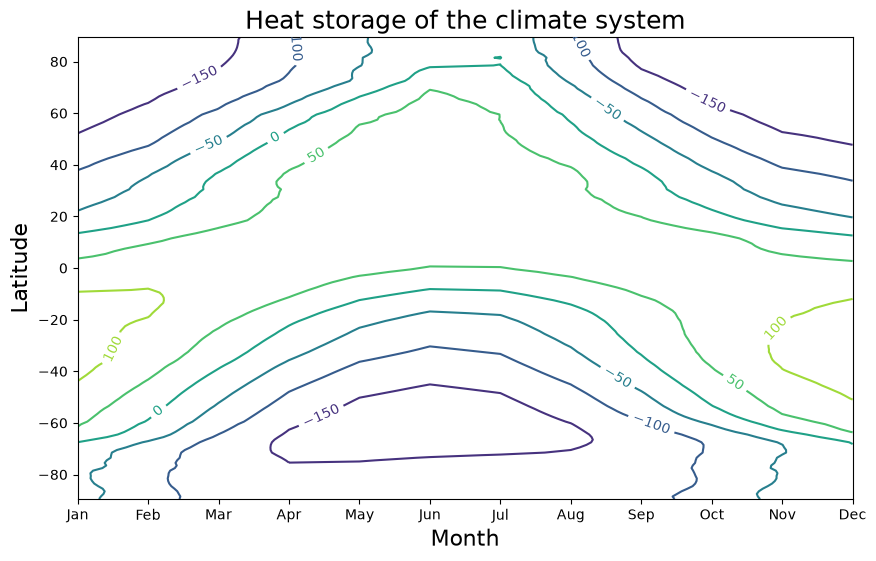

In [15]:
fig, ax = plt.subplots(figsize=fsize)
CS = ax.contour(months, ceres.lat, ztoa_net_all_clim.transpose())
ax.clabel(CS, CS.levels, inline=True, fontsize=10)
ax.set_xlabel('Month', fontsize=16 )
ax.set_ylabel('Latitude', fontsize=16 )
ax.set_title('Heat storage of the climate system', fontsize=18 );

### Meridional energy transport

:::{figure} https://ars.els-cdn.com/content/image/1-s2.0-S0169809515002070-gr8.jpg
:alt: Seasonal heat transport
:width: 600px

The late February and August seasonal total heat transport: (a) shows the seasonal transports as highlighted and their average (thin solid line) contrasted against the heavy solid line representing the 14 year annual mean. The slight non-zero transport at the SH pole for both is indicative of the heat gained by the system. (b) The seasonal transports as in (b) highlighting the Tropical Trough Zone (TTZ) as a gray shaded region between 12 S and 20 N. Source: {cite:t}`Stephens:2015a`
:::



### Precipitation and the ITCZ

:::{figure} https://media.springernature.com/full/springer-static/image/art%3A10.1007%2Fs00382-013-1767-z/MediaObjects/382_2013_1767_Fig1_HTML.gif?as=webp
:alt: Annual mean precipitation
:width: 800px

The annual mean precipitation from the National Oceanographic and Atmospheric Administration’s Climate Prediction Center’s (NOAACPC) merged analysis (Xie and Arkin 1996). Blue lines indicate the meridional location of the maximum in the Tropics at each longitude. The zonal mean is shown on the left and is co-plotted with the zonal mean of the local maximum (blue lines) and the precipitation centroid (dashed black lines). Source: {cite:t}`Marshall:2014a`
:::



## Inferring energy transport from net radiation

:::{tip}
For an alternative derivation, see [this chapter in Brian Rose's *The Climate Laboratory*](https://brian-rose.github.io/ClimateLaboratoryBook/courseware/advanced-heat-transport/#id-4-the-energy-budget-for-a-zonal-band)
:::

Consider the energy budget of a column:

$$ \frac{\partial E}{\partial t} = F_{net}^{\downarrow} - \nabla \cdot (\vec{v} E) $$

where
- $E$ is the energy per unit area stored in the column (J m$^{-2}$)
- $F_{net}^{\downarrow}$ is the net downward flux of energy at TOA (W m$^{-2}$)
- $\vec{v} E$ is the total flux of the energy by the fluid atmosphere and ocean

Averaging over a long period of time and **assuming global energy balance**, the left hand side is negligible so that

$$ \overline{F_{net}^{\downarrow}} = \overline{\nabla \cdot (\vec{v} E)} $$

The flux divergence can be expressed in spherical coordinates as

$$ \overline{\nabla \cdot (\vec{v} E)} = \frac{1}{a \cos\phi} \frac{\partial}{\partial \lambda}(\overline{u E}) + \frac{1}{a \cos\phi} \frac{\partial}{\partial \phi} \overline{(v E \cos\phi )} $$
with this standard notation:
- $a$ is the radius of the Earth
- $\phi$ is latitude
- $\lambda$ is longitude
- $u$ and $v$ are the eastward and northward components of the velocity field


We want to measure the total energy transport across latitude lines, so we need to integrate in longitude.

The increment in arc length around a latitude circle is $a \cos\phi d\lambda$

So, integrating around latitude circles, the balance condition is

$$ \int_0^{2\pi} \overline{F_{net}^{\downarrow}} a \cos\phi d\lambda = \int_0^{2\pi} \frac{\partial}{\partial \lambda}(\overline{u E}) d\lambda + \int_0^{2\pi} \frac{\partial}{\partial \phi} \overline{(v E \cos\phi )} d\lambda $$
and the first term on the RHS drops out (why?).

The total northward meridional energy transport at any latitude is

$$ \mathcal{H} = \int_0^{2\pi} \frac{\partial}{\partial \phi} \overline{v E} a \cos \phi d\lambda $$

so we can calculate this by integrating the energy balance condition in latitude starting from the South Pole and working northward:

\begin{align}
\mathcal{H}(\phi_0) &= \int_{-\frac{\pi}{2}}^{\phi_0} \int_0^{2\pi} \frac{\partial}{\partial \phi} \overline{(v E a \cos\phi )} d\lambda d\phi \\
&= \int_{-\frac{\pi}{2}}^{\phi_0} \int_0^{2\pi} \overline{F_{net}^{\downarrow}} a^2 \cos\phi d\lambda
\end{align}

:::{note} The key result
We can infer the meridional energy transport by simply knowing the net radiative flux at the TOA!

We don't need to know anything about the actual motions or thermodynamic states in the atmosphere and ocean.
:::